# ABLA — Raw versus Summarized ESN State Representation

This controlled multi-temperature ablation compares four XGBoost input representations:

1. **raw ESN states only**;
2. **summarized ESN trajectories only**;
3. **raw ESN states + scalar thermal features**; and
4. **summarized ESN trajectories + scalar thermal features**.

Everything else is held constant: the 0–3 s analysis window, absolute smoothed sensor inputs, five ESN channels, ESN and XGBoost hyperparameters, reservoir seeds, target transformation, prediction clipping, and 14-fold leave-one-material-out (LOMO) evaluation.

The absolute smoothed Primary and Secondary readings enter the reservoir directly. There is **no baseline centering, min–max normalization, or StandardScaler** in this notebook. Operating temperature is metadata for diagnostics and is not an additional regressor predictor.

Raw states are interpolated onto 31 common times from 0 to 3 s and flattened in time-major order. With 20 units, this produces `31 × 20 = 620` raw-state predictors. The summarized branch calculates nine statistics for every unit, producing `9 × 20 = 180` predictors.


# 1. Imports and fixed controlled settings


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


In [2]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 3.0)
RAW_STATE_TIME_POINTS = 31

ESN_PARAMS = {
    "res_size": 20,
    "leak_rate": 0.30,
    "input_magnitude": 1.00,
    "spectral_radius": 0.90,
    "washout": 0,
}
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "min_child_weight": 5,
    "reg_alpha": 0.10,
    "reg_lambda": 10.0,
}

# Three reservoirs reduce dependence on one random reservoir realization.
# Set to (42,) for a faster screening run, but use all three for the final comparison.
RESERVOIR_SEEDS = (42, 43, 44)
RANDOM_STATE = 42
CLIP_PREDICTIONS_TO_TRAIN_RANGE = True

CONDITIONS = {
    "A_raw_ESN_states": {"esn_representation": "raw", "include_thermal": False},
    "B_summarized_ESN_states": {"esn_representation": "summarized", "include_thermal": False},
    "C_raw_ESN_plus_thermal": {"esn_representation": "raw", "include_thermal": True},
    "D_summarized_ESN_plus_thermal": {"esn_representation": "summarized", "include_thermal": True},
}

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_STEM = "ABLA_raw_vs_summarized_ESN_with_without_thermal_absolute_smoothed_0to3_fixed_HP_LOMO"

print("Conditions:", list(CONDITIONS))
print("Analysis window:", ANALYSIS_WINDOW)
print("Raw-state grid points:", RAW_STATE_TIME_POINTS)
print("ESN HPs:", ESN_PARAMS)
print("XGBoost HPs:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)


Conditions: ['A_raw_ESN_states', 'B_summarized_ESN_states', 'C_raw_ESN_plus_thermal', 'D_summarized_ESN_plus_thermal']
Analysis window: (0.0, 3.0)
Raw-state grid points: 31
ESN HPs: {'res_size': 20, 'leak_rate': 0.3, 'input_magnitude': 1.0, 'spectral_radius': 0.9, 'washout': 0}
XGBoost HPs: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 10.0}
Reservoir seeds: (42, 43, 44)


## Why the hyperparameters remain fixed

This notebook measures the effect of changing the **representation supplied to XGBoost**. Separate optimization for every branch would confound representation choice with hyperparameter choice. The same deliberately moderate ESN and regularized XGBoost configuration is therefore used throughout.

Because the raw-state branch has substantially more predictors than the summarized branch, the results compare complete pipelines rather than equal feature counts. Feature counts and per-material errors must be reported alongside pooled performance.


# 2. Load all trials and assign standard material properties


In [3]:
STANDARD_PROPERTIES = {
    "ps_foam": {"k": .034, "rho": 25., "cp": 1400.},
    "pu_foam": {"k": .043, "rho": 30., "cp": 1400.},
    "cork": {"k": .043, "rho": 240., "cp": 1800.},
    "wood": {"k": .150, "rho": 700., "cp": 1700.},
    "pdms": {"k": .150, "rho": 970., "cp": 1460.},
    "gypsum": {"k": .170, "rho": 800., "cp": 1090.},
    "cement": {"k": .290, "rho": 1440., "cp": 750.},
    "graphite": {"k": 100., "rho": 1820., "cp": 710.},
    "bismuth": {"k": 8.1, "rho": 9780., "cp": 130.},
    "titanium": {"k": 21.9, "rho": 4506., "cp": 523.},
    "nickel": {"k": 90.9, "rho": 8908., "cp": 461.},
    "iron": {"k": 80.4, "rho": 7874., "cp": 449.},
    "aluminum": {"k": 237., "rho": 2700., "cp": 897.},
    "copper": {"k": 401., "rho": 8960., "cp": 385.},
}
ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite", "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium", "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron", "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    folder = DATA_ROOT / temperature
    for path in sorted(folder.glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            continue
        frame["Temperature"] = temperature
        frame["Temperature_C"] = float(temperature.rstrip("C"))
        frames.append(frame)
if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary", "Temperature_C"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature", "Temperature_C"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError("At least one material name does not have a recognized alias.")
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda material: STANDARD_PROPERTIES[material][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (
    DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str)
)
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)
print("Raw trial count:", DATA["trial_id"].nunique())


Raw trial count: 336


# 3. Contact alignment and the common 0–3 s analysis interval


In [4]:
def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=.30, skip_samples=5):
    clean = (
        trial[["Time", "Primary"]].dropna().sort_values("Time")
        .drop_duplicates("Time").reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Invalid sequence for contact detection.")
    time, signal = time[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(signal))
    if window % 2 == 0:
        window -= 1
    smooth = savgol_filter(signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(time[elbow])


aligned_trials = {}
metadata_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 8:
        warnings.warn(f"Skipping {trial_id}: too few samples in 0–3 s.")
        continue
    trial = trial.reset_index(drop=True)
    aligned_trials[trial_id] = trial
    metadata_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })

METADATA = pd.DataFrame(metadata_rows).sort_values("trial_id").reset_index(drop=True)
print("Aligned trials retained:", len(METADATA))
print("Materials:", METADATA["Sample"].nunique())
display(METADATA.groupby(["Temperature", "Sample"]).size().unstack(fill_value=0))


Aligned trials retained: 336
Materials: 14


Sample,aluminum,bismuth,cement,copper,cork,graphite,gypsum,iron,nickel,pdms,ps_foam,pu_foam,titanium,wood
Temperature,,,,,,,,,,,,,,
30C,6,6,6,6,6,6,6,6,6,6,6,6,6,6
40C,6,6,6,6,6,6,6,6,6,6,6,6,6,6
50C,6,6,6,6,6,6,6,6,6,6,6,6,6,6
60C,6,6,6,6,6,6,6,6,6,6,6,6,6,6


# 4. Absolute-smoothed ESN inputs and fixed reservoir

For every trial, Primary and Secondary are smoothed but retain their absolute processed-file levels. The five ESN channels are:

1. smoothed Primary;
2. smoothed Secondary;
3. Primary − Secondary;
4. (d\mathrm{Primary}/dt); and
5. (d\mathrm{Secondary}/dt).

The channels enter the reservoir directly. No fold-local or per-trial scaling is applied.


In [5]:
def smooth_signal(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= 5 else values.copy()
    )


def esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    return np.column_stack([
        primary,
        secondary,
        primary - secondary,
        np.gradient(primary, time),
        np.gradient(secondary, time),
    ])


class ManualReservoir:
    def __init__(self, random_state):
        self.res_size = int(ESN_PARAMS["res_size"])
        self.leak_rate = float(ESN_PARAMS["leak_rate"])
        self.washout = int(ESN_PARAMS["washout"])
        rng = np.random.default_rng(random_state)
        self.Win = (
            rng.random((self.res_size, 1 + 5)) - 0.5
        ) * ESN_PARAMS["input_magnitude"]
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * ESN_PARAMS["spectral_radius"]

    def run(self, sequence):
        x = np.zeros((self.res_size, 1))
        states = []
        for row in np.asarray(sequence, float):
            proposed = np.tanh(
                self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x
            )
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        states = np.asarray(states)
        if len(states) <= self.washout:
            raise ValueError("The reservoir sequence is shorter than the washout.")
        return states[self.washout:]


# 5. Raw-state and summarized-state trial representations


In [6]:
FIXED_STATE_TIME = np.linspace(*ANALYSIS_WINDOW, RAW_STATE_TIME_POINTS)


def flatten_states(time, states):
    # Interpolate every unit and flatten time-major: all units at t0, then t1, etc.
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    interpolated = np.column_stack([
        np.interp(FIXED_STATE_TIME, time, states[:, unit])
        for unit in range(states.shape[1])
    ])
    return {
        f"esn_state_t{time_index:03d}_u{unit:03d}": float(interpolated[time_index, unit])
        for time_index in range(interpolated.shape[0])
        for unit in range(interpolated.shape[1])
    }


def summarize_states(time, states):
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    output = {}
    for unit in range(states.shape[1]):
        x = states[:, unit]
        prefix = f"esn_u{unit:03d}"
        output.update({
            f"{prefix}_mean": float(np.mean(x)),
            f"{prefix}_std": float(np.std(x)),
            f"{prefix}_min": float(np.min(x)),
            f"{prefix}_max": float(np.max(x)),
            f"{prefix}_initial": float(x[0]),
            f"{prefix}_net_change": float(x[-1] - x[0]),
            f"{prefix}_slope": float(np.polyfit(time, x, 1)[0]),
            f"{prefix}_mean_abs": float(np.mean(np.abs(x))),
            f"{prefix}_abs_auc": float(np.trapezoid(np.abs(x), time)),
        })
    return output


print("Raw ESN predictors per trial:", RAW_STATE_TIME_POINTS * ESN_PARAMS["res_size"])
print("Summarized ESN predictors per trial:", 9 * ESN_PARAMS["res_size"])


Raw ESN predictors per trial: 620
Summarized ESN predictors per trial: 180


# 6. Scalar thermal features calculated over the same 0–3 s interval

The thermal block is calculated independently for every trial and never uses the regression target. It contains response magnitude, area, rate, and three one-second slope intervals for Primary, Secondary, and their difference. This same block is added unchanged to conditions C and D.


In [7]:
THERMAL_SLOPE_WINDOWS = {
    "early": (0.0, 1.0),
    "middle": (1.0, 2.0),
    "late": (2.0, 3.0),
}


def signal_slope(time, values, window):
    mask = (time >= window[0]) & (time <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    difference = primary - secondary
    result = {}
    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"thermal_{name}_final_change"] = float(change[-1])
        result[f"thermal_{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"thermal_{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"thermal_{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"thermal_{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))
        for window_name, window in THERMAL_SLOPE_WINDOWS.items():
            result[f"thermal_{name}_{window_name}_slope"] = signal_slope(time, signal, window)

    primary_auc = result["thermal_primary_response_auc"]
    result["thermal_secondary_primary_auc_ratio"] = (
        result["thermal_secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["thermal_initial_sensor_difference"] = float(difference[0])
    result["thermal_final_sensor_difference"] = float(difference[-1])
    return result


THERMAL_FEATURES = pd.DataFrame([
    {"trial_id": trial_id, **extract_thermal_features(trial)}
    for trial_id, trial in aligned_trials.items()
]).set_index("trial_id").sort_index()
print("Scalar thermal predictors:", THERMAL_FEATURES.shape[1])
display(THERMAL_FEATURES.head())


Scalar thermal predictors: 27


,thermal_primary_final_change,thermal_primary_max_abs_change,thermal_primary_response_auc,thermal_primary_max_abs_rate,thermal_primary_rate_auc,thermal_primary_early_slope,thermal_primary_middle_slope,thermal_primary_late_slope,thermal_secondary_final_change,thermal_secondary_max_abs_change,...,thermal_difference_max_abs_change,thermal_difference_response_auc,thermal_difference_max_abs_rate,thermal_difference_rate_auc,thermal_difference_early_slope,thermal_difference_middle_slope,thermal_difference_late_slope,thermal_secondary_primary_auc_ratio,thermal_initial_sensor_difference,thermal_final_sensor_difference
trial_id,,,,,,,,,,,,,,,,,,,,,
30C__aluminum_trial_1,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.608193e-07,-2.301865e-07,-7.393007e-07,7.393007e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.999514e-07,1.968456e-07,0.108039,-0.000040,-0.000043
30C__aluminum_trial_2,-0.000003,0.000003,0.000007,0.000004,0.000003,-0.000002,-5.356806e-07,-2.233930e-07,-7.777622e-07,7.777622e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.770283e-07,1.954258e-07,0.126702,-0.000040,-0.000043
30C__aluminum_trial_3,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-4.910211e-07,-2.395687e-07,-8.261538e-07,8.261538e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.242352e-07,1.772203e-07,0.137653,-0.000040,-0.000043
30C__aluminum_trial_4,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.429477e-07,-2.277291e-07,-7.784615e-07,7.784615e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-3.218157e-07,1.910936e-07,0.130203,-0.000040,-0.000043
30C__aluminum_trial_5,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.403697e-07,-2.391434e-07,-8.559441e-07,8.559441e-07,...,0.000002,0.000006,0.000003,0.000003,-0.000002,-3.093597e-07,2.082574e-07,0.151386,-0.000041,-0.000043


# 7. Precompute seed-specific ESN feature tables

Precomputation is leakage-safe here because the absolute-smoothed input transformation does not estimate any parameter from other trials or materials. Only XGBoost is fitted inside each LOMO training fold. Every seed uses its own fixed reservoir, and the same seed-specific features are used by all four branches.


In [8]:
RAW_FEATURES_BY_SEED = {}
SUMMARY_FEATURES_BY_SEED = {}

for seed in RESERVOIR_SEEDS:
    print(f"Generating ESN features for seed {seed} ...")
    reservoir = ManualReservoir(seed)
    raw_rows, summary_rows = [], []
    for trial_id in METADATA["trial_id"]:
        trial = aligned_trials[trial_id]
        time = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time[ESN_PARAMS["washout"]:]
        raw_rows.append({"trial_id": trial_id, **flatten_states(state_time, states)})
        summary_rows.append({"trial_id": trial_id, **summarize_states(state_time, states)})
    RAW_FEATURES_BY_SEED[seed] = pd.DataFrame(raw_rows).set_index("trial_id").sort_index()
    SUMMARY_FEATURES_BY_SEED[seed] = pd.DataFrame(summary_rows).set_index("trial_id").sort_index()

FEATURE_COUNTS = pd.DataFrame([
    {"condition": condition,
     "esn_predictors": (
         RAW_FEATURES_BY_SEED[RESERVOIR_SEEDS[0]].shape[1]
         if settings["esn_representation"] == "raw"
         else SUMMARY_FEATURES_BY_SEED[RESERVOIR_SEEDS[0]].shape[1]
     ),
     "thermal_predictors": THERMAL_FEATURES.shape[1] if settings["include_thermal"] else 0}
    for condition, settings in CONDITIONS.items()
])
FEATURE_COUNTS["total_predictors"] = (
    FEATURE_COUNTS["esn_predictors"] + FEATURE_COUNTS["thermal_predictors"]
)
display(FEATURE_COUNTS)


Generating ESN features for seed 42 ...
Generating ESN features for seed 43 ...
Generating ESN features for seed 44 ...


,condition,esn_predictors,thermal_predictors,total_predictors
0,A_raw_ESN_states,620,0,620
1,B_summarized_ESN_states,180,0,180
2,C_raw_ESN_plus_thermal,620,27,647
3,D_summarized_ESN_plus_thermal,180,27,207


# 8. Four-branch leakage-safe LOMO evaluation


In [9]:
def make_regressor(seed):
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(seed),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **XGB_PARAMS,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    target_range = float(np.ptp(y_true))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": float(r2_score(y_true, y_pred)) if target_range > 0 else np.nan,
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def feature_table_for_condition(condition, seed):
    settings = CONDITIONS[condition]
    esn = (
        RAW_FEATURES_BY_SEED[seed]
        if settings["esn_representation"] == "raw"
        else SUMMARY_FEATURES_BY_SEED[seed]
    )
    if settings["include_thermal"]:
        return esn.join(THERMAL_FEATURES, how="left", validate="one_to_one")
    return esn


logo = LeaveOneGroupOut()
prediction_rows, fold_rows = [], []

for fold, (train_idx, test_idx) in enumerate(
    logo.split(METADATA, groups=METADATA["Sample"]), start=1
):
    train_meta = METADATA.iloc[train_idx].reset_index(drop=True)
    test_meta = METADATA.iloc[test_idx].reset_index(drop=True)
    train_ids = train_meta["trial_id"].tolist()
    test_ids = test_meta["trial_id"].tolist()
    y_train = train_meta[TARGET].to_numpy(float)
    y_test = test_meta[TARGET].to_numpy(float)
    held_out = str(test_meta["Sample"].iloc[0])
    print(f"Fold {fold:02d}/14: held out {held_out}")

    for condition in CONDITIONS:
        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = feature_table_for_condition(condition, seed)
            X_train = features.loc[train_ids].reset_index(drop=True)
            X_test = features.loc[test_ids].reset_index(drop=True)
            model = make_regressor(seed)
            model.fit(X_train, y_train)
            prediction = model.predict(X_test)
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                prediction = np.clip(prediction, y_train.min(), y_train.max())
            seed_predictions.append(prediction)

        prediction = np.mean(seed_predictions, axis=0)
        residual = prediction - y_test
        rmse = float(np.sqrt(np.mean(residual ** 2)))
        fold_rows.append({
            "condition": condition,
            "fold": fold,
            "held_out_material": held_out,
            "n": len(y_test),
            "mae": float(np.mean(np.abs(residual))),
            "rmse": rmse,
            "nrmse_training_range": rmse / float(np.ptp(y_train)),
            "mean_error_bias": float(np.mean(residual)),
            "median_ape_pct": float(np.median(np.abs(residual / y_test)) * 100),
        })
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            prediction_rows.append({
                "condition": condition,
                "fold": fold,
                "trial_id": meta_row["trial_id"],
                "Temperature": meta_row["Temperature"],
                "Temperature_C": meta_row["Temperature_C"],
                "Sample": meta_row["Sample"],
                "Trial": meta_row["Trial"],
                "y_true": y_test[row_index],
                "y_pred": prediction[row_index],
            })

OOF = pd.DataFrame(prediction_rows)
FOLD_METRICS = pd.DataFrame(fold_rows)
OVERALL = pd.DataFrame([
    {"condition": condition, **pooled_metrics(part["y_true"], part["y_pred"])}
    for condition, part in OOF.groupby("condition", sort=False)
]).merge(FEATURE_COUNTS, on="condition", how="left", validate="one_to_one")
OVERALL = OVERALL.sort_values("nrmse_range").reset_index(drop=True)
display(OVERALL)


Fold 01/14: held out aluminum
Fold 02/14: held out bismuth
Fold 03/14: held out cement
Fold 04/14: held out copper
Fold 05/14: held out cork
Fold 06/14: held out graphite
Fold 07/14: held out gypsum
Fold 08/14: held out iron
Fold 09/14: held out nickel
Fold 10/14: held out pdms
Fold 11/14: held out ps_foam
Fold 12/14: held out pu_foam
Fold 13/14: held out titanium
Fold 14/14: held out wood


,condition,n,mae,rmse,nrmse_range,r2,median_ape_pct,esn_predictors,thermal_predictors,total_predictors
0,D_summarized_ESN_plus_thermal,336,4520.978480,8116.525269,0.218432,0.475593,51.384683,180,27,207
1,B_summarized_ESN_states,336,4707.292109,8316.406909,0.223811,0.449447,51.147995,180,0,180
2,C_raw_ESN_plus_thermal,336,4875.752709,8574.783748,0.230765,0.414706,56.809029,620,27,647
3,A_raw_ESN_states,336,5169.386961,8976.303961,0.241571,0.358609,56.323365,620,0,620


# 9. Pooled performance and per-material stability


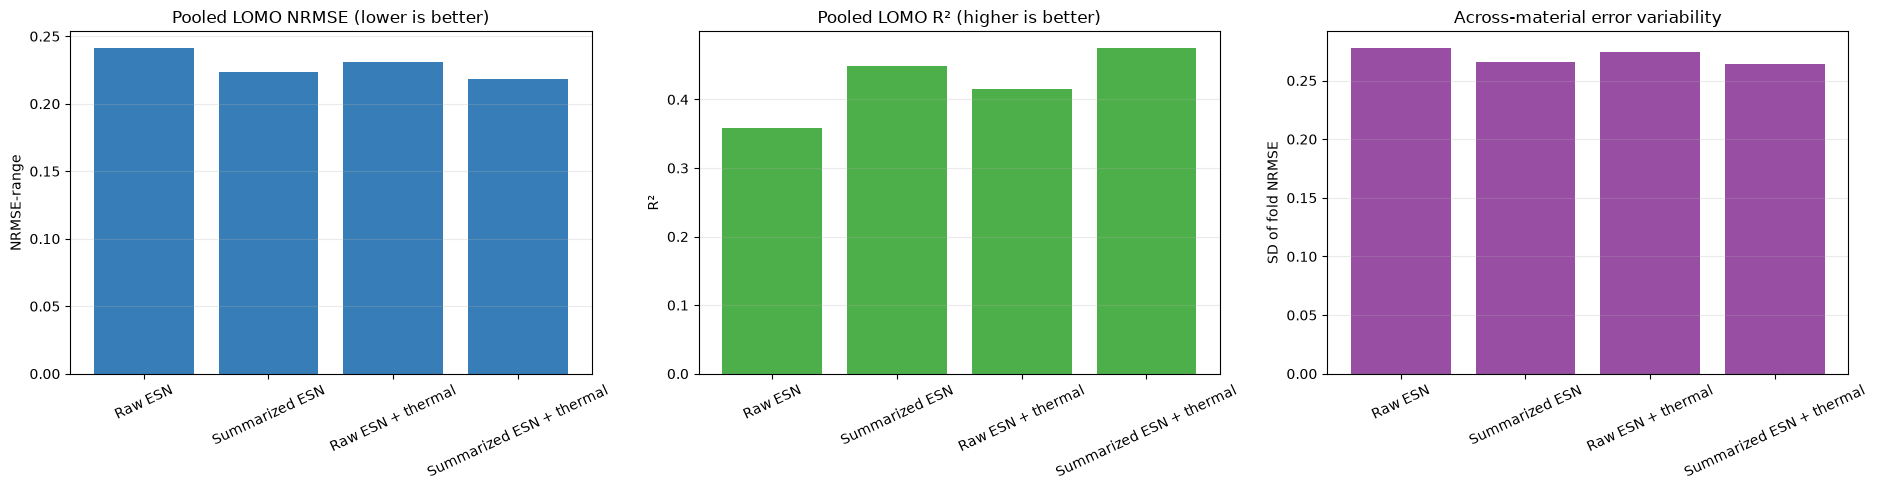

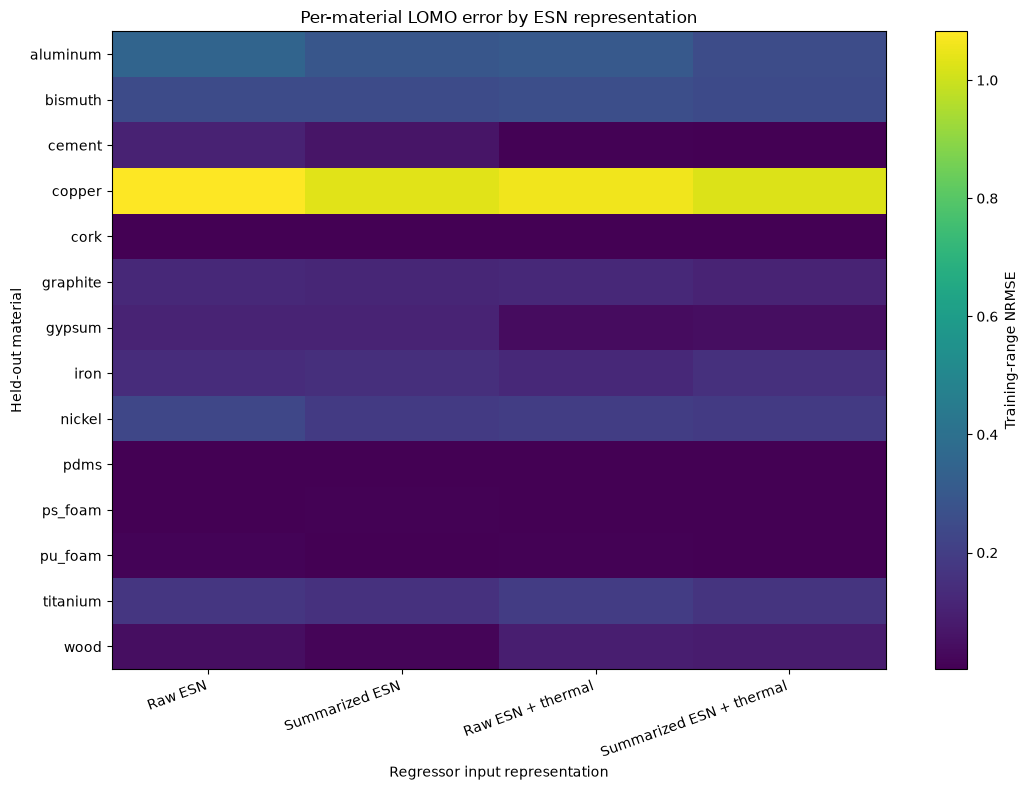

In [10]:
condition_order = list(CONDITIONS)
labels = [
    "Raw ESN",
    "Summarized ESN",
    "Raw ESN + thermal",
    "Summarized ESN + thermal",
]

ordered = OVERALL.set_index("condition").loc[condition_order]
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].bar(labels, ordered["nrmse_range"], color="#377eb8")
axes[0].set_title("Pooled LOMO NRMSE (lower is better)")
axes[0].set_ylabel("NRMSE-range")
axes[1].bar(labels, ordered["r2"], color="#4daf4a")
axes[1].set_title("Pooled LOMO R² (higher is better)")
axes[1].set_ylabel("R²")
fold_sd = FOLD_METRICS.groupby("condition")["nrmse_training_range"].std(ddof=1).loc[condition_order]
axes[2].bar(labels, fold_sd, color="#984ea3")
axes[2].set_title("Across-material error variability")
axes[2].set_ylabel("SD of fold NRMSE")
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()

heatmap = FOLD_METRICS.pivot(
    index="held_out_material", columns="condition", values="nrmse_training_range"
)[condition_order]
fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(heatmap, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(condition_order)), labels, rotation=20, ha="right")
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set_title("Per-material LOMO error by ESN representation")
ax.set_xlabel("Regressor input representation")
ax.set_ylabel("Held-out material")
fig.colorbar(image, ax=ax, label="Training-range NRMSE")
plt.tight_layout()
plt.show()


# 10. Direct ablation effects


In [11]:
metric_lookup = OVERALL.set_index("condition")
contrasts = [
    ("Raw versus summarized, ESN only", "A_raw_ESN_states", "B_summarized_ESN_states"),
    ("Raw versus summarized, with thermal", "C_raw_ESN_plus_thermal", "D_summarized_ESN_plus_thermal"),
    ("Thermal addition to raw ESN", "C_raw_ESN_plus_thermal", "A_raw_ESN_states"),
    ("Thermal addition to summarized ESN", "D_summarized_ESN_plus_thermal", "B_summarized_ESN_states"),
]
contrast_rows = []
for comparison, first, reference in contrasts:
    contrast_rows.append({
        "comparison": comparison,
        "first_condition": first,
        "reference_condition": reference,
        "delta_nrmse_first_minus_reference": (
            metric_lookup.loc[first, "nrmse_range"] - metric_lookup.loc[reference, "nrmse_range"]
        ),
        "delta_r2_first_minus_reference": (
            metric_lookup.loc[first, "r2"] - metric_lookup.loc[reference, "r2"]
        ),
    })
CONTRASTS = pd.DataFrame(contrast_rows)
display(CONTRASTS)

paired = FOLD_METRICS.pivot(
    index="held_out_material", columns="condition", values="nrmse_training_range"
)[condition_order]
paired["raw_minus_summary_ESN_only"] = (
    paired["A_raw_ESN_states"] - paired["B_summarized_ESN_states"]
)
paired["raw_minus_summary_with_thermal"] = (
    paired["C_raw_ESN_plus_thermal"] - paired["D_summarized_ESN_plus_thermal"]
)
display(paired.sort_values("raw_minus_summary_ESN_only"))


,comparison,first_condition,reference_condition,delta_nrmse_first_minus_reference,delta_r2_first_minus_reference
0,"Raw versus summarized, ESN only",A_raw_ESN_states,B_summarized_ESN_states,0.017759,-0.090838
1,"Raw versus summarized, with thermal",C_raw_ESN_plus_thermal,D_summarized_ESN_plus_thermal,0.012333,-0.060888
2,Thermal addition to raw ESN,C_raw_ESN_plus_thermal,A_raw_ESN_states,-0.010806,0.056097
3,Thermal addition to summarized ESN,D_summarized_ESN_plus_thermal,B_summarized_ESN_states,-0.005379,0.026147


condition,A_raw_ESN_states,B_summarized_ESN_states,C_raw_ESN_plus_thermal,D_summarized_ESN_plus_thermal,raw_minus_summary_ESN_only,raw_minus_summary_with_thermal
held_out_material,,,,,,
iron,0.140547,0.147898,0.125307,0.151498,-0.007351,-0.026191
ps_foam,0.005723,0.007273,0.006412,0.006551,-0.001549,-0.000139
pdms,0.005823,0.006227,0.005618,0.005885,-0.000403,-0.000267
cork,0.002461,0.002783,0.004466,0.004734,-0.000321,-0.000268
bismuth,0.250977,0.249785,0.261463,0.246957,0.001192,0.014506
gypsum,0.110116,0.108647,0.037646,0.041229,0.001470,-0.003583
pu_foam,0.011510,0.005120,0.010040,0.006537,0.006390,0.003502
graphite,0.125551,0.116742,0.126054,0.111622,0.008809,0.014432
titanium,0.174442,0.155529,0.195467,0.166261,0.018913,0.029205


# 11. Actual-versus-predicted comparison


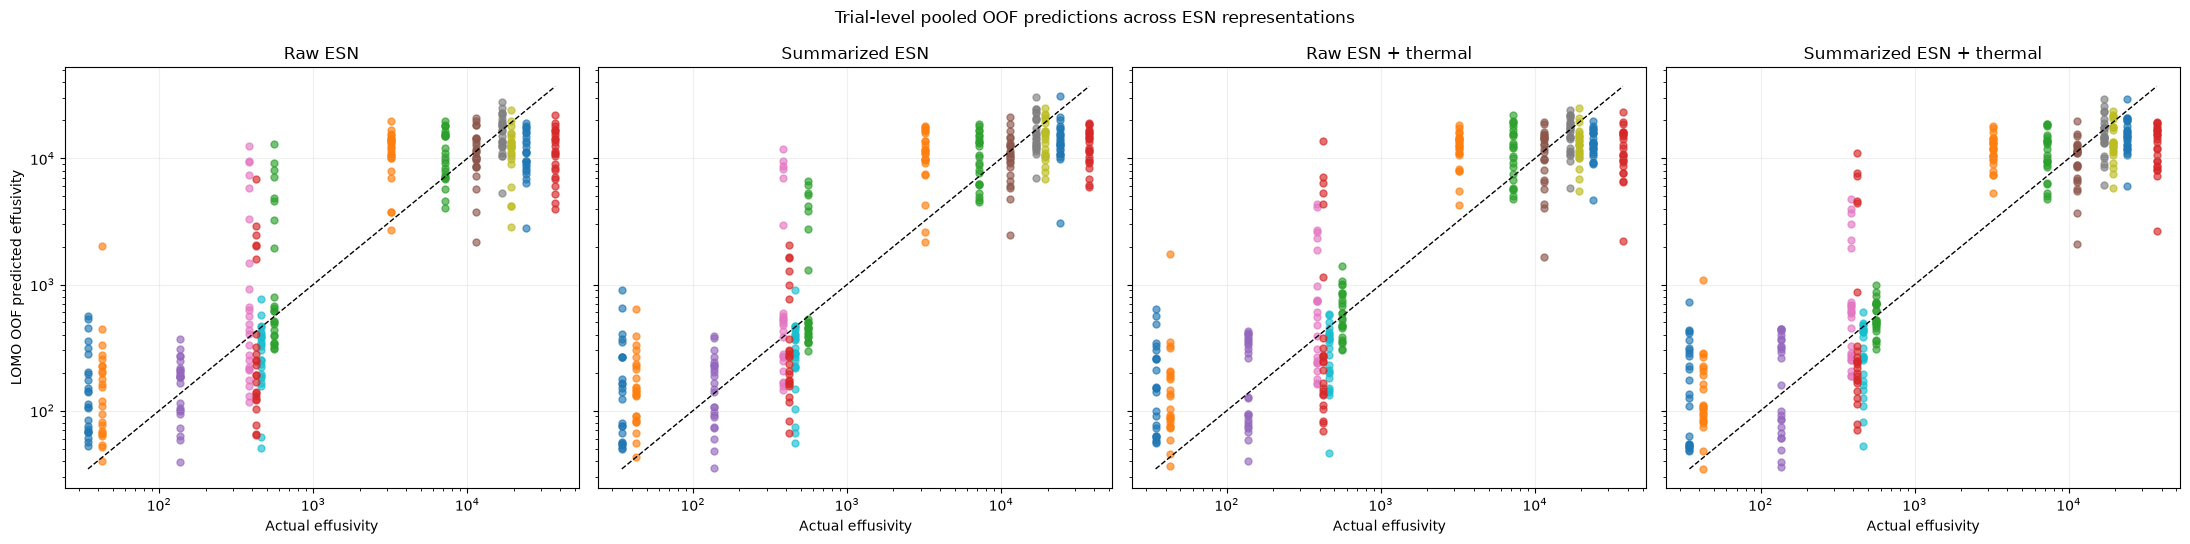

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharex=True, sharey=True)
positive = OOF[["y_true", "y_pred"]].to_numpy(float)
positive = positive[np.isfinite(positive) & (positive > 0)]
minimum, maximum = float(positive.min()), float(positive.max())
for ax, condition, label in zip(axes, condition_order, labels):
    part = OOF[OOF["condition"] == condition]
    for material, material_part in part.groupby("Sample"):
        ax.scatter(material_part["y_true"], material_part["y_pred"], s=25, alpha=.65)
    ax.plot([minimum, maximum], [minimum, maximum], "k--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(label)
    ax.set_xlabel("Actual effusivity")
    ax.grid(alpha=.2)
axes[0].set_ylabel("LOMO OOF predicted effusivity")
fig.suptitle("Trial-level pooled OOF predictions across ESN representations")
plt.tight_layout()
plt.show()


# 12. Save outputs and provenance


In [13]:
OVERALL_FILE = RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv"
FOLD_FILE = RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv"
OOF_FILE = RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv"
CONTRAST_FILE = RESULTS_DIR / f"{RESULT_STEM}_contrasts.csv"
FEATURE_COUNT_FILE = RESULTS_DIR / f"{RESULT_STEM}_feature_counts.csv"
PROVENANCE_FILE = RESULTS_DIR / f"{RESULT_STEM}_provenance.json"

OVERALL.to_csv(OVERALL_FILE, index=False)
FOLD_METRICS.to_csv(FOLD_FILE, index=False)
OOF.to_csv(OOF_FILE, index=False)
CONTRASTS.to_csv(CONTRAST_FILE, index=False)
FEATURE_COUNTS.to_csv(FEATURE_COUNT_FILE, index=False)

provenance = {
    "purpose": "Controlled comparison of raw and summarized ESN state representations, with and without scalar thermal features",
    "temperature_folders": list(TEMPERATURE_FOLDERS),
    "target": TARGET,
    "analysis_window": list(ANALYSIS_WINDOW),
    "input_preprocessing": {
        "sensor_values": "absolute processed-file Primary and Secondary values",
        "smoothing": "Savitzky-Golay applied equally to every branch",
        "baseline_centering": False,
        "minmax_normalization": False,
        "standard_scaler": False,
        "esn_channels": ["Primary", "Secondary", "Primary-Secondary", "dPrimary/dt", "dSecondary/dt"],
    },
    "raw_state_representation": {
        "time_points": RAW_STATE_TIME_POINTS,
        "time_grid_seconds": FIXED_STATE_TIME.tolist(),
        "flatten_order": "time-major",
    },
    "summaries_per_unit": ["mean", "std", "min", "max", "initial", "net_change", "slope", "mean_abs", "abs_auc"],
    "scalar_thermal_features": list(THERMAL_FEATURES.columns),
    "temperature_used_as_regressor_feature": False,
    "conditions": CONDITIONS,
    "esn_parameters": ESN_PARAMS,
    "xgb_parameters": XGB_PARAMS,
    "reservoir_seeds": list(RESERVOIR_SEEDS),
    "validation": "14-fold leave-one-material-out; metrics pooled over 336 OOF trial predictions per condition",
    "fairness_note": "No condition-specific hyperparameter optimization was performed.",
}
with PROVENANCE_FILE.open("w") as file:
    json.dump(provenance, file, indent=2)

print("Saved:")
for path in (OVERALL_FILE, FOLD_FILE, OOF_FILE, CONTRAST_FILE, FEATURE_COUNT_FILE, PROVENANCE_FILE):
    print(" -", path)


Saved:
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_raw_vs_summarized_ESN_with_without_thermal_absolute_smoothed_0to3_fixed_HP_LOMO_overall_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_raw_vs_summarized_ESN_with_without_thermal_absolute_smoothed_0to3_fixed_HP_LOMO_fold_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_raw_vs_summarized_ESN_with_without_thermal_absolute_smoothed_0to3_fixed_HP_LOMO_oof_predictions.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/W

# Interpretation checklist

- Compare raw versus summarized states first **without** thermal features.
- Repeat that contrast when both representations receive the same thermal block.
- Compare conditions C−A and D−B to isolate the contribution of thermal features.
- Use pooled NRMSE and (R^2) together with per-material fold errors; a pooled improvement may hide deterioration on specific held-out materials.
- Raw states preserve sampled temporal position but create many more predictors and may overfit the relatively small number of training trials.
- Summaries reduce dimensionality but discard the exact timing of intermediate events.
- The best-looking reservoir trajectories are not automatically the best predictive representation; the LOMO results decide the comparison.
